## Bird ID Project

### Installs and Imports

In [ ]:
!pip install h5py --quiet
!pip install audiomentations --quiet
!pip install torchlibrosa --quiet
!pip install mlflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!git clone https://github.com/qiuqiangkong/audioset_tagging_cnn.git

Cloning into 'audioset_tagging_cnn'...
remote: Enumerating objects: 714, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 714 (delta 131), reused 120 (delta 120), pack-reused 560 (from 2)
Receiving objects: 100% (714/714), 3.99 MiB | 16.42 MiB/s, done.
Resolving deltas: 100% (412/412), done.


In [ ]:
CHECKPOINT_PATH_ORIGINAL="Cnn14_DecisionLevelAtt_mAP=0.425.pth"
!wget -O $CHECKPOINT_PATH_ORIGINAL https://zenodo.org/records/3987831/files/Cnn14_DecisionLevelAtt_mAP=0.425.pth?download=1

--2026-08-05 16:42:32--  https://zenodo.org/records/3987831/files/Cnn14_DecisionLevelAtt_mAP=0.425.pth?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 331757477 (316M) [application/octet-stream]
Saving to: ‘Cnn14_DecisionLevelAtt_mAP=0.425.pth’

Cnn14_DecisionLevel 100%[===================>] 316.39M  2.41MB/s    in 1m 59s  

2026-08-05 16:44:33 (2.65 MB/s) - ‘Cnn14_DecisionLevelAtt_mAP=0.425.pth’ saved [331757477/331757477]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import json
import ast
import h5py
from tqdm import tqdm
import logging

import torch
import torch.nn as nn
import torchaudio as ta
import librosa
import torchlibrosa
import h5py
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from audiomentations import Compose, AddGaussianNoise, Gain, AddBackgroundNoise
from sklearn.metrics import average_precision_score, f1_score
import mlflow

import sys
sys.path.append("audioset_tagging_cnn/pytorch")
from models import Cnn14_DecisionLevelAtt

In [ ]:
# CONFIG
SAMPLE_RATE = 32000
WINDOW_SIZE=1024
HOP_SIZE=320
MEL_BINS=64
FMIN=50
FMAX=14000
CLASSES_NUM_PRETRAINED=527
CLASSES_NUM = 264
CROP_LENGTH_SEC = 10
CROP_LENGTH_SAMPLES = SAMPLE_RATE * CROP_LENGTH_SEC  # 320,000
SHARD_SIZE = ... # e.g., 500 clips per HDF5 shard file — pick based on Drive I/O comfort
SEED = 42

device = ("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

PROJECT_DIR = "/content/drive/MyDrive/bird-id-project"
RAW_DATA_DIR = "/content/drive/MyDrive/bird-id-project/data"
OUTPUT_DIR = "/content/drive//MyDrive/bird-id-project/data/processed/"
CHECKPOINT_PATH_STAGE_A = "/content/drive/MyDrive/bird-id-project/training_runs/cnn14_att_stage_a_v3/best_model.pth"

### Utility Functions

In [ ]:
def filter_labels_to_species(labels):
  for i, label in enumerate(labels):
    idx = label.find("_")
    if idx != -1:
      labels[i] = label[idx + 1: ]

  return labels

def load_metadata(path):
  train_csv = pd.read_csv(os.path.join(path, "train.csv"))
  metadata_df = train_csv[["ebird_code", "species", "secondary_labels", "filename"]].copy()

  # Convert the secondary_labels column from str to list
  metadata_df["secondary_labels"] = metadata_df["secondary_labels"].apply(ast.literal_eval)
  metadata_df["secondary_labels"] = metadata_df["secondary_labels"].apply(filter_labels_to_species)
  return metadata_df

In [ ]:
def build_name_to_code_dict(metadata_df):
  name_to_code = {}
  for _, row in metadata_df.iterrows():
    name_to_code[row["species"].lower().strip()] = row["ebird_code"]

  return name_to_code

In [ ]:
# Get count of all secondary labels
def get_secondary_label_count(metadata_df):
  total = sum(len(labels) for labels in metadata_df["secondary_labels"])
  return total

def filter_secondary_labels(labels):
  codes = []
  for label in labels:
    code = name_to_code.get(label.lower().strip())
    if code:
      codes.append(code)
  return codes


In [ ]:
def load_json(filepath):
  if not os.path.isfile(filepath):
    raise FileNotFoundError(f"File not found: {filepath}")

  if not filepath.lower().endswith(".json"):
    raise ValueError("File is not a json file.")

  try:
    with open(filepath, "r") as f:
      return  json.load(f)

  except json.JSONDecodeError as e:
    raise ValueError(f"Invalid JSON in file {filepath}") from e

## Data Loading and Preprocessing

Load the data from kaggle into the local storage, then convert the files into .wav, then into hdf5 files.

#### Kaggle Download

In [ ]:
!pip install kaggle --quiet

In [ ]:
import kagglehub

In [ ]:
from google.colab import files
files.upload()   # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
path = kagglehub.competition_download('birdsong-recognition')

100%|██████████| 22.1G/22.1G [04:17<00:00, 92.2MB/s]

Extracting files...


### Loading From Drive

In [ ]:
metadata_df = load_metadata(RAW_DATA_DIR)
print(metadata_df.head())

  ebird_code           species  \
0     aldfly  Alder Flycatcher   
1     aldfly  Alder Flycatcher   
2     aldfly  Alder Flycatcher   
3     aldfly  Alder Flycatcher   
4     aldfly  Alder Flycatcher   

                                    secondary_labels      filename  
0  [Least Flycatcher, Tennessee Warbler, Gray Cat...  XC134874.mp3  
1                                                 []  XC135454.mp3  
2                                                 []  XC135455.mp3  
3                      [Gray Catbird, Cedar Waxwing]  XC135456.mp3  
4                                                 []  XC135457.mp3  


In [ ]:
# Total number of training samples
print("Total samples:")
print(len(metadata_df))

# How many samples have secondary labels
print("Samples with secondary labels:")
print(metadata_df["secondary_labels"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum())

Total samples:
21375
Samples with secondary labels:
8225


### Create species name: ebird_code dictionary

In [ ]:
print(name_to_code)

{'alder flycatcher': 'aldfly', 'american avocet': 'ameavo', 'american bittern': 'amebit', 'american crow': 'amecro', 'american goldfinch': 'amegfi', 'american kestrel': 'amekes', 'buff-bellied pipit': 'amepip', 'american redstart': 'amered', 'american robin': 'amerob', 'american wigeon': 'amewig', 'american woodcock': 'amewoo', 'american tree sparrow': 'amtspa', "anna's hummingbird": 'annhum', 'ash-throated flycatcher': 'astfly', "baird's sandpiper": 'baisan', 'bald eagle': 'baleag', 'baltimore oriole': 'balori', 'sand martin': 'banswa', 'barn swallow': 'barswa', 'black-and-white warbler': 'bawwar', 'belted kingfisher': 'belkin1', "bell's sparrow": 'belspa2', "bewick's wren": 'bewwre', 'black-billed cuckoo': 'bkbcuc', 'black-billed magpie': 'bkbmag1', 'blackburnian warbler': 'bkbwar', 'black-capped chickadee': 'bkcchi', 'black-chinned hummingbird': 'bkchum', 'black-headed grosbeak': 'bkhgro', 'blackpoll warbler': 'bkpwar', 'black-throated sparrow': 'bktspa', 'black phoebe': 'blkpho', '

In [ ]:
with open("label_map.json", "w") as f:
  json.dump(name_to_code, f)

In [ ]:
name_to_code_path = os.path.join(RAW_DATA_DIR, "species_to_ebird_map.json")
name_to_code = load_json(name_to_code_path)

label_map_path = os.path.join(RAW_DATA_DIR, "label_map.json")
label_map = load_json(label_map_path)

Not all secondary label species are primary labels. Therefore, we will ignore secondary labels that dont match the primary labels since we do not have training data for them.

In [ ]:
secondary_all = set()
for labels in metadata_df["secondary_labels"]:
    secondary_all.update(labels)  # assuming you've parsed to a list already

unmatched = {s for s in secondary_all if s.lower().strip() not in name_to_code}
print(len(unmatched), "unmatched secondary species")
print(unmatched)

720 unmatched secondary species
{"Cabanis's Wren", 'Bearded Reedling', 'Blue-throated Mountain-gem', 'Great Reed Warbler', 'Black Vulture', 'Tufted Flycatcher', 'Common Eider', 'Gray-capped Flycatcher', 'Purple Sandpiper', 'Hispaniolan Woodpecker', 'Happy Wren', 'House Crow', 'Masked Tityra', 'Violet-crowned Hummingbird', 'Golden Tanager', 'Least Tern', 'Green Jay', 'Black-chinned Sparrow', 'Black Thrush', 'Roseate Tern', 'Chestnut-collared Longspur', 'Black-polled Yellowthroat', 'Black Kite', 'Northwestern Crow', 'White-winged Crossbill', 'Brazilian Tanager', 'Lapland Longspur', 'New Zealand Fantail', 'Common Redshank', 'Golden-browed Warbler', 'Citrine Wagtail', "Bell's Vireo", 'Spanish Sparrow', 'Brambling', 'Yellowhammer', 'Necklaced Spinetail', 'Ruddy-breasted Seedeater', 'Buff-winged Starfrontlet', 'Oak Titmouse', 'Bar-tailed Godwit', 'Parasitic Jaeger', 'Cuban Blackbird', 'Green-backed Trogon', 'Yellow-crowned Night-Heron', 'Russet-crowned Warbler', 'Cinnamon Attila', 'Eurasian 

In [ ]:
before_count = get_secondary_label_count(metadata_df)
metadata_df["secondary_labels"] = metadata_df["secondary_labels"].apply(filter_secondary_labels)
print(metadata_df.head())
after_count = get_secondary_label_count(metadata_df)

  ebird_code           species  secondary_labels      filename
0     aldfly  Alder Flycatcher  [leafly, fiespa]  XC134874.mp3
1     aldfly  Alder Flycatcher                []  XC135454.mp3
2     aldfly  Alder Flycatcher                []  XC135455.mp3
3     aldfly  Alder Flycatcher          [cedwax]  XC135456.mp3
4     aldfly  Alder Flycatcher                []  XC135457.mp3


In [ ]:
print(f"Before filtering: {before_count}, after filtering: {after_count}, difference: {before_count - after_count}")
print(f"Percentage of secondary labels filtered: {(before_count - after_count)/before_count * 100:.2f}%")

Before filtering: 21259, after filtering: 14816, difference: 6443
Percentage of secondary labels filtered: 30.31%


### Build a Label Encoding Function

In [ ]:
def encode_labels(primary_label, secondary_labels, label_map):
  vec = np.zeros(len(label_map), dtype=np.float32)
  vec[label_map[primary_label]] = 1.0
  for label in secondary_labels:
    if label in label_map:
      vec[label_map[label]] = 1.0
  return vec

load_and_resample(filepath)
Load mp3 (librosa or torchaudio)
Resample to SAMPLE_RATE if not already
Convert to mono if stereo
Return raw waveform as float32 numpy array

### Load and Resample Data

In [ ]:
def mp3_to_wav(input_dir, output_dir, target_sr=32000):
  for ebird_folder in os.listdir(input_dir):
    folder_path = os.path.join(input_dir, ebird_folder)
    if not os.path.isdir(folder_path):
      continue
    for filename in os.listdir(folder_path):
      if not filename.endswith("mp3"):
        continue

      mp3_path = os.path.join(folder_path, filename)
      wav_filename = os.path.splitext(filename)[0] + ".wav"
      wav_path = os.path.join(output_dir, wav_filename)

      if os.path.exists(wav_path):
        continue

      try:
        waveform, sr = ta.load(mp3_path)
        # If the waveform is stereo, reduce channels to mono by taking the mean of both channels
        if waveform.shape[0] > 1:
          waveform = waveform.mean(dim=0, keepdim=True)

        # Resample if sr is not equal to target_sr
        if sr != target_sr:
          waveform = ta.functional.resample(waveform, sr, target_sr)
        ta.save(wav_path, waveform, target_sr)
      except Exception as e:
        print(f"Skipping {mp3_path}: {e}")

In [ ]:
train_data_dir = os.path.join(path, "train_audio")
output_dir = "/content/processed_data/wav_files"
os.makedirs(output_dir, exist_ok=True)

mp3_to_wav(train_data_dir, output_dir, SAMPLE_RATE)

Skipping /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/comyel/XC362478.mp3: Failed to decode audio samples: decodeAVFrame, /__w/torchcodec/torchcodec/meta-pytorch/torchcodec/src/torchcodec/_core/SingleStreamDecoder.cpp:1397, Could not push packet to decoder: Invalid data found when processing input
Skipping /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/larspa/XC163940.mp3: Failed to decode audio samples: decodeAVFrame, /__w/torchcodec/torchcodec/meta-pytorch/torchcodec/src/torchcodec/_core/SingleStreamDecoder.cpp:1397, Could not push packet to decoder: Invalid data found when processing input
Skipping /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/eawpew/XC286805.mp3: Failed to decode audio samples: decodeAVFrame, /__w/torchcodec/torchcodec/meta-pytorch/torchcodec/src/torchcodec/_core/SingleStreamDecoder.cpp:1397, Could not push packet to decoder: Invalid data found when processing input
Skipping /root/.cache/kagglehub

In [ ]:
# Need to change metadata filename to remove the extension
metadata_df.reset_index()
metadata_df["filename"] = metadata_df["filename"].apply(lambda f: os.path.splitext(f)[0])
metadata_df["filename_wav"] = metadata_df["filename"].apply(lambda f: os.path.splitext(f)[0] + ".wav")

metadata_df = metadata_df.set_index("filename")
print(metadata_df.head())

         ebird_code           species  secondary_labels  filename_wav
filename                                                             
XC134874     aldfly  Alder Flycatcher  [leafly, fiespa]  XC134874.wav
XC135454     aldfly  Alder Flycatcher                []  XC135454.wav
XC135455     aldfly  Alder Flycatcher                []  XC135455.wav
XC135456     aldfly  Alder Flycatcher          [cedwax]  XC135456.wav
XC135457     aldfly  Alder Flycatcher                []  XC135457.wav


### Convert WAV to HDF5 Format

In [ ]:
def write_shard(clip_batch, shard_path, wav_dir, metadata_df, label_map):
  tmp_path = shard_path + ".tmp"
  with h5py.File(tmp_path, "w") as f:
    for filename in clip_batch:
      clip_id = os.path.splitext(filename)[0]

      if clip_id not in metadata_df.index:
        print(f"No metadata for {clip_id}, skipping.")
        continue

      try:
        row = metadata_df.loc[clip_id]
        label_vec = encode_labels(row["ebird_code"], row["secondary_labels"], label_map)

        wav_path = os.path.join(wav_dir, filename)
        waveform, _ = ta.load(wav_path)
        waveform = waveform.squeeze(0).numpy()

        f.create_dataset(f"{clip_id}/waveform", data=waveform, compression="gzip", compression_opts=4)
        f.create_dataset(f"{clip_id}/label", data=label_vec)
      except Exception as e:
        print(f"Skipping {clip_id}: {e}")
  os.rename(tmp_path, shard_path)


In [ ]:
def build_shards(wav_dir, output_dir, metadata_df, label_map, shard_size=500):
  all_filenames = [f for f in os.listdir(wav_dir) if f.endswith(".wav")]
  shards = [all_filenames[i:i+shard_size] for i in range(0, len(all_filenames), shard_size)]

  for shard_idx, clip_batch in enumerate(shards):
    shard_path = os.path.join(output_dir, f"shard_{shard_idx:04d}.h5")

    if os.path.exists(shard_path):
      continue

    write_shard(clip_batch, shard_path, wav_dir, metadata_df, label_map)
    print(f"Wrote shard {shard_idx+1}/{len(shards)}")

wav_dir = "/content/processed_data/wav_files"
OUTPUT_DIR = "/content/drive/MyDrive/bird-id-project/data/processed/"
build_shards(wav_dir, OUTPUT_DIR, metadata_df, label_map)

FileNotFoundError: [Errno 2] No such file or directory: '/content/processed_data/wav_files'

In [ ]:
class BirdSongDataset(Dataset):
  def __init__(self, metadata_df, shard_dir, fold, augment=None, sample_rate=32000, crop_length_sec=10, is_train=True):
    if is_train:
      self.df = metadata_df[metadata_df["fold"] != fold]
    else:
      self.df = metadata_df[metadata_df["fold"] == fold]

    self.sample_rate = sample_rate
    self.crop_length = crop_length_sec
    self.crop_samples = int(sample_rate * crop_length_sec)
    self.is_train = is_train
    self._open_files = {}

    self.clip_to_shard = self._build_shard_index(shard_dir)
    self.df = self.df[self.df.index.isin(self.clip_to_shard.keys())]
    self.augment = augment

  def __len__(self):
    return len(self.df)

  def _crop_or_pad(self, waveform):
    length = waveform.shape[0]
    if length < self.crop_samples:
      pad = self.crop_samples - length
      waveform = np.pad(waveform, (0, pad), mode="constant") # right padding
    else:
      if self.is_train:
        start = np.random.randint(0, length - self.crop_samples + 1)
      else:
        start = (length - self.crop_samples) // 2
      waveform = waveform[start:start + self.crop_samples]
    return waveform

  def _get_file_handle(self, shard_path):
    if shard_path not in self._open_files:
      self._open_files[shard_path] = h5py.File(shard_path, "r")
    return self._open_files[shard_path]

  def _build_shard_index(self, shard_dir):
    index = {}
    for shard_name in os.listdir(shard_dir):
      if not shard_name.endswith(".h5"):
        continue
      shard_path = os.path.join(shard_dir, shard_name)
      with h5py.File(shard_path, "r") as f:
        for clip_id in f.keys():
          index[clip_id] = shard_path
    return index

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    clip_id = row.name
    shard_path = self.clip_to_shard[clip_id]

    f = self._get_file_handle(shard_path)
    waveform = f[f"{clip_id}/waveform"][:]
    label = f[f"{clip_id}/label"][:]

    waveform = self._crop_or_pad(waveform)

    if self.is_train:
      waveform = self.augment(samples=waveform, sample_rate=self.sample_rate)

    return torch.from_numpy(waveform).float(), torch.from_numpy(label).float()


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

metadata_df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(metadata_df, metadata_df["ebird_code"])):
  metadata_df.iloc[val_idx, metadata_df.columns.get_loc("fold")] = fold_idx

In [ ]:
shard_dir = "/content/drive/MyDrive/bird-id-project/data/processed"
background_noise_dir = "/content/drive/MyDrive/bird-id-project/data/background_noise"

augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.04, p=0.5),
    Gain(min_gain_db=-4.0, max_gain_db=0.4, p=0.5),
    AddBackgroundNoise(sounds_path=background_noise_dir, min_snr_db=5, max_snr_db=20, p=0.5)
])

## Model Loading

In [ ]:
def get_model_architecture(pretrained=False):
  classes_num = CLASSES_NUM_PRETRAINED if pretrained else CLASSES_NUM
  return Cnn14_DecisionLevelAtt(
    sample_rate=SAMPLE_RATE,
    window_size=WINDOW_SIZE,
    hop_size=HOP_SIZE,
    mel_bins=MEL_BINS,
    fmin=FMIN,
    fmax=FMAX,
    classes_num=classes_num
)

In [ ]:
# Load the model into pytorch
model = get_model_architecture(pretrained=True)

In [ ]:
# Load the checkpoint (PANN)
checkpoint = torch.load(CHECKPOINT_PATH_ORIGINAL, map_location="cpu")
result = model.load_state_dict(checkpoint["model"])
print(result)

<All keys matched successfully>


In [ ]:
print(model)

Cnn14_DecisionLevelAtt(
  (spectrogram_extractor): Spectrogram(
    (stft): STFT(
      (conv_real): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
      (conv_imag): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
    )
  )
  (logmel_extractor): LogmelFilterBank()
  (spec_augmenter): SpecAugmentation(
    (time_dropper): DropStripes()
    (freq_dropper): DropStripes()
  )
  (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_block1): ConvBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_block2): ConvBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), b

In [ ]:
# Change the model classification head
num_classes = len(label_map)
model.att_block.att = nn.Conv1d(model.att_block.att.in_channels, num_classes, kernel_size=(1, ), stride=(1, ))
model.att_block.cla = nn.Conv1d(model.att_block.cla.in_channels, num_classes, kernel_size=(1, ), stride=(1, ))
model.att_block.bn_att = nn.BatchNorm1d(num_classes, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

model = model.to(device)
print(model.att_block)

AttBlock(
  (att): Conv1d(2048, 264, kernel_size=(1,), stride=(1,))
  (cla): Conv1d(2048, 264, kernel_size=(1,), stride=(1,))
  (bn_att): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [ ]:
# Load the checkpoint (STAGE A - frozen backbone)
checkpoint = torch.load(CHECKPOINT_PATH_STAGE_A, map_location="cpu")
result = model.load_state_dict(checkpoint)
print(result)

<All keys matched successfully>


In [ ]:
# Freeze the model parameters except for the attention block pooling head
for name, param in model.named_parameters():
  if "att_block" in name:
    param.requires_grad = True
  else:
    param.requires_grad = False

model = model.to(device)

In [ ]:
for name, param in model.named_parameters():
  print(f"{name}: {param.requires_grad}")

spectrogram_extractor.stft.conv_real.weight: False
spectrogram_extractor.stft.conv_imag.weight: False
logmel_extractor.melW: False
bn0.weight: True
bn0.bias: True
conv_block1.conv1.weight: True
conv_block1.conv2.weight: True
conv_block1.bn1.weight: True
conv_block1.bn1.bias: True
conv_block1.bn2.weight: True
conv_block1.bn2.bias: True
conv_block2.conv1.weight: True
conv_block2.conv2.weight: True
conv_block2.bn1.weight: True
conv_block2.bn1.bias: True
conv_block2.bn2.weight: True
conv_block2.bn2.bias: True
conv_block3.conv1.weight: True
conv_block3.conv2.weight: True
conv_block3.bn1.weight: True
conv_block3.bn1.bias: True
conv_block3.bn2.weight: True
conv_block3.bn2.bias: True
conv_block4.conv1.weight: True
conv_block4.conv2.weight: True
conv_block4.bn1.weight: True
conv_block4.bn1.bias: True
conv_block4.bn2.weight: True
conv_block4.bn2.bias: True
conv_block5.conv1.weight: True
conv_block5.conv2.weight: True
conv_block5.bn1.weight: True
conv_block5.bn1.bias: True
conv_block5.bn2.weight:

In [ ]:
# Define the loss function
class PANNsLoss(nn.Module):
  def __init__(self, framewise_weight=0.5):
    super().__init__()
    self.framewise_weight = framewise_weight
    self.bce = nn.BCELoss()

  def forward(self, clipwise_output, framewise_output, target):
    clipwise_loss = self.bce(clipwise_output, target)

    framewise_max = framewise_output.max(dim=1)[0]
    framewise_loss = self.bce(framewise_max, target)

    total_loss = clipwise_loss + self.framewise_weight * framewise_loss
    return total_loss, clipwise_loss, framewise_loss

In [ ]:
def compute_metrics(preds, targets, threshold=0.5):
  preds_np = preds.detach().cpu().numpy()
  targets_np = targets.detach().cpu().numpy()

  preds_binary = (preds_np >= threshold).astype(int)
  f1 = f1_score(targets_np, preds_binary, average="macro", zero_division=0)

  mAP = average_precision_score(targets_np, preds_np, average="macro")
  np.nan_to_num(mAP).mean()

  return {
      "mAP": mAP,
      "f1": f1,
  }

In [ ]:
def validate(model, loader, criterion, device, threshold=0.5):
  model.eval()
  running_loss = 0.0
  all_preds, all_targets = [], []
  with torch.no_grad():
    for waveform, label in tqdm(loader):
      waveform, label = waveform.to(device), label.to(device)
      output = model(waveform)
      loss, _, _ = criterion(output["clipwise_output"], output["framewise_output"], label)
      running_loss += loss.item()
      all_preds.append(output["clipwise_output"].cpu())
      all_targets.append(label.cpu())

  all_preds= torch.cat(all_preds)
  all_targets = torch.cat(all_targets)
  metrics = compute_metrics(all_preds, all_targets, threshold=threshold)
  return running_loss / len(loader), metrics


In [ ]:
def get_preds(model, loader, device):
  model.eval()
  all_preds, all_targets = [], []

  with torch.no_grad():
    for waveform, label in tqdm(loader):
      waveform = waveform.to(device)
      output = model(waveform)
      all_preds.append(output["clipwise_output"].cpu())
      all_targets.append(label)

  all_preds = torch.cat(all_preds).numpy()
  all_targets = torch.cat(all_targets).numpy()

  return all_preds, all_targets


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
  model.train()
  running_loss, running_clip_loss, running_frame_loss = 0.0, 0.0, 0.0
  for waveform, label in tqdm(loader):
    waveform, label = waveform.to(device), label.to(device)

    optimizer.zero_grad()
    output = model(waveform)
    loss, clip_loss, frame_loss = criterion(output["clipwise_output"], output["framewise_output"], label)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    running_clip_loss += clip_loss.item()
    running_frame_loss += frame_loss.item()

  n_batches = len(loader)

  return running_loss/n_batches, running_clip_loss/n_batches, running_frame_loss/n_batches

In [ ]:
def save_checkpoint(checkpoint, checkpoint_dir, filename):
  os.makedirs(checkpoint_dir, exist_ok=True)
  path = os.path.join(checkpoint_dir, filename)
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")

In [ ]:
def load_checkpoint(checkpoint_path, model, optimizer, scheduler, device):
  checkpoint = torch.load(checkpoint_path, map_location=device)

  model.load_state_dict(checkpoint["model_state_dict"])
  optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
  torch.set_rng_state(checkpoint["random_state"])
  if checkpoint["cuda_random_state"] is not None and torch.cuda.is_available():
    torch.cuda.set_rng_state(checkpoint["cuda_random_state"])

  best_val_mAP = checkpoint["best_val_mAP"]
  history = checkpoint["history"]
  start_epoch = checkpoint["epoch"] + 1


  print(f"Resumed from epoch {checkpoint["epoch"]}")
  return start_epoch, best_val_mAP, history

### Training Config

In [ ]:
def training_start_config():
  num_epochs = 15
  learning_rate=1e-4
  # Define optimizer
  optimizer = torch.optim.AdamW(
      filter(lambda p: p.requires_grad, model.parameters()),
      lr=learning_rate,
      weight_decay=0.01
  )

  criterion = PANNsLoss(framewise_weight=0.5)

  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      optimizer, T_max=num_epochs
  )

  history = {"train_loss": [], "train_clip_loss": [], "train_frame_loss": [],
            "val_loss": [],
            "mAP": [], "f1": []}

  best_val_mAP = 0.0

  return num_epochs, learning_rate, optimizer, criterion, scheduler, history, best_val_mAP

In [ ]:
batch_size = 64
train_dataset = BirdSongDataset(metadata_df, shard_dir, fold=0, augment=augment, is_train=True)
val_dataset = BirdSongDataset(metadata_df, shard_dir, fold=0, is_train=False)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False, num_workers=2)

In [ ]:
# Get params when starting a new training run
num_epochs, learning_rate, optimizer, criterion, scheduler, history, best_val_mAP = training_start_config()
start_epoch = 0

In [ ]:
# Get params when resuming a training run from a checkpoint
start_epoch, best_val_mAP, history = load_checkpoint()

In [ ]:
logging.getLogger("mlflow").setLevel(logging.ERROR)
# Training Loop

run_name = f"cnn14_att_stage_b_v1"
run_dir_drive = os.path.join(PROJECT_DIR, f"training_runs/{run_name}")
checkpoint_dir_drive = os.path.join(run_dir_drive, "checkpoints")
os.makedirs(run_dir_drive, exist_ok = True)
os.makedirs(checkpoint_dir_drive, exist_ok = True)

run_dir_local = "/content/training_runs"
checkpoint_dir_local = os.path.join(run_dir_local, "checkpoints")
os.makedirs(run_dir_local, exist_ok=True)
os.makedirs(checkpoint_dir_local, exist_ok=True)
model_path = os.path.join(run_dir_local, "best_model.pth")

mlflow_path = "sqlite:////content/drive/MyDrive/bird-id-project/mlflow.db"
mlflow.set_tracking_uri(mlflow_path)
mlflow.set_experiment("cnn14_att_stage_b")

with mlflow.start_run(run_name=run_name):
  mlflow.log_params({
      "stage": "full_finetune",
      "lr": optimizer.param_groups[0]["lr"],
      "batch_size": batch_size,
      "crop_length_sec": CROP_LENGTH_SEC,
      "framewise_weight": 0.5,
      "fold": 0
  })

  for epoch in range(start_epoch, num_epochs):
    train_loss, train_clip_loss, train_frame_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )
    val_loss, val_metrics = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_clip_loss"].append(train_clip_loss)
    history["train_frame_loss"].append(train_frame_loss)
    history["val_loss"].append(val_loss)
    history["mAP"].append(val_metrics["mAP"])
    history["f1"].append(val_metrics["f1"])

    mlflow.log_metrics({
        "train_loss": train_loss,
        "train_clip_loss": train_clip_loss,
        "train_frame_loss": train_frame_loss,
        "val_loss": val_loss,
        **val_metrics
    }, step=epoch)

    print(f"Epoch {epoch+1}/{num_epochs} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, "
        f"mAP: {val_metrics['mAP']:.4f}, f1: {val_metrics['f1']:.4f}")

    if val_metrics["mAP"] > best_val_mAP:
      best_val_mAP = val_metrics["mAP"]
      model_name = f"cnn14_mAP={best_val_mAP:.4f}"
      mlflow.pytorch.log_model(model, name=f"stage_b_v1", serialization_format="pickle")
      torch.save(model.state_dict(), model_path)

    scheduler.step()

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_mAP": best_val_mAP,
        "history": history,
        "random_state": torch.get_rng_state(),
        "cuda_random_state": torch.cuda.get_rng_state() if torch.cuda.is_available() else None
    }

    checkpoint_name = run_name + f"_epoch_{epoch + 1}.pth"
    save_checkpoint(checkpoint, checkpoint_dir_local, checkpoint_name)

    if (epoch + 1) % 1 == 0: # CHANGE TO 5 LATER
      latest_checkpoint_src = os.path.join(checkpoint_dir_local, checkpoint_name)
      latest_checkpoint_dst = os.path.join(checkpoint_dir_drive, checkpoint_name)
      shutil.copy2(latest_checkpoint_src, latest_checkpoint_dst)

      if os.path.exists(model_path):
        model_path_dst = os.path.join(run_dir_drive, "best_model.pth")
        shutil.copy2(model_path, model_path_dst)
      print(f"Synced checkpoints to Drive at epoch {epoch + 1}")

  history_path = os.path.join(run_dir_drive, "history.json")
  with open(history_path, "w") as f:
    json.dump(history, f)

100%|██████████| 67/67 [03:56<00:00,  3.54s/it]


Epoch 1/15 — train_loss: 0.0547, val_loss: 0.0537, mAP: 0.0663, f1: 0.0084
Saved checkpoint to /content/training_runs/checkpoints/cnn14_att_stage_b_v1_epoch_1.pth
Synced checkpoints to Drive at epoch 1


100%|██████████| 67/67 [03:57<00:00,  3.54s/it]


Epoch 2/15 — train_loss: 0.0527, val_loss: 0.0526, mAP: 0.0931, f1: 0.0153
Saved checkpoint to /content/training_runs/checkpoints/cnn14_att_stage_b_v1_epoch_2.pth
Synced checkpoints to Drive at epoch 2


100%|██████████| 67/67 [04:01<00:00,  3.60s/it]


...

Epoch 13/15 — train_loss: 0.0437, val_loss: 0.0462, mAP: 0.2849, f1: 0.1467
Saved checkpoint to /content/training_runs/checkpoints/cnn14_att_stage_b_v1_epoch_13.pth
Synced checkpoints to Drive at epoch 13


100%|██████████| 67/67 [04:25<00:00,  3.97s/it]


Epoch 14/15 — train_loss: 0.0436, val_loss: 0.0461, mAP: 0.2818, f1: 0.1437
Saved checkpoint to /content/training_runs/checkpoints/cnn14_att_stage_b_v1_epoch_14.pth
Synced checkpoints to Drive at epoch 14


100%|██████████| 67/67 [04:20<00:00,  3.88s/it]


Epoch 15/15 — train_loss: 0.0436, val_loss: 0.0460, mAP: 0.2915, f1: 0.1546
Saved checkpoint to /content/training_runs/checkpoints/cnn14_att_stage_b_v1_epoch_15.pth
Synced checkpoints to Drive at epoch 15


### Plot Results

In [ ]:
# Load trained model from path
model_path = "/content/drive/MyDrive/bird-id-project/training_runs/cnn14_att_stage_b_v1/best_model.pth"

model = get_model_architecture(pretrained=False)

model_weights = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(model_weights)
model = model.to(device)

<All keys matched successfully>

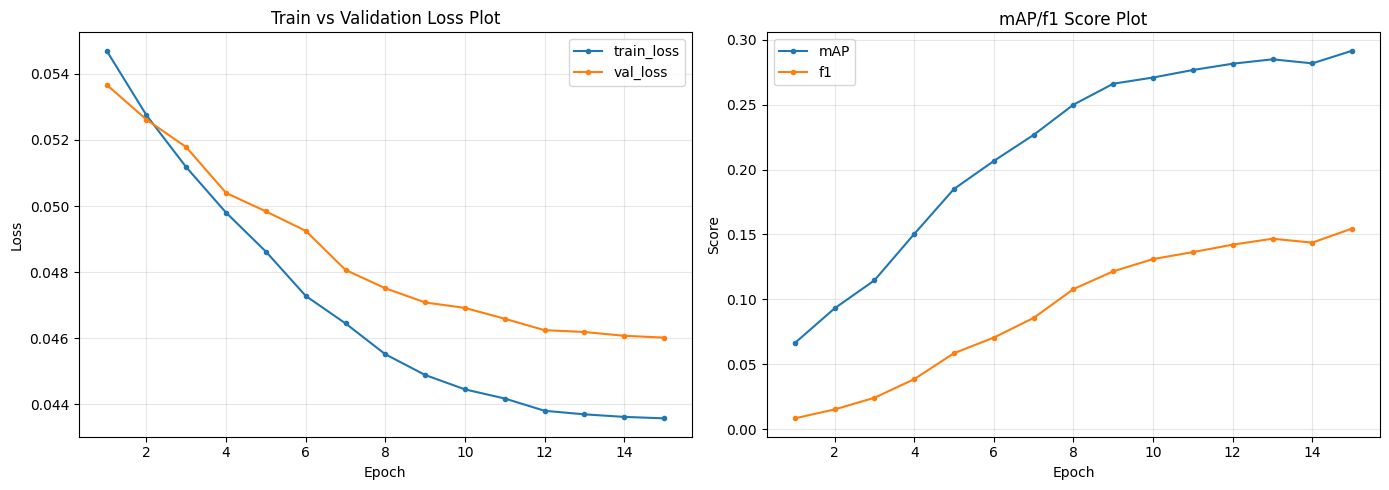

In [ ]:
stage_b_path = "/content/drive/MyDrive/bird-id-project/training_runs/cnn14_att_stage_b_v1"
history_path = os.path.join(stage_b_path, "history.json")
fig_path = os.path.join(stage_b_path, "stage_b_plots.png")

history = load_json(history_path)
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Loss curves
axes[0].plot(epochs, history["train_loss"], label="train_loss", marker="o", markersize=3)
axes[0].plot(epochs, history["val_loss"], label="val_loss", marker="o", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Validation Loss Plot")
axes[0].legend()
axes[0].grid(alpha=0.3)

# mAP / f1 curves
axes[1].plot(epochs, history["mAP"], label="mAP", marker="o", markersize=3)
axes[1].plot(epochs, history["f1"], label="f1", marker="o", markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("mAP/f1 Score Plot")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(fig_path, dpi=250)
plt.show()

In [ ]:
# Top 15 best/worst classes

preds, targets = get_preds(model, val_loader, device)
per_class_ap = average_precision_score(targets, preds, average=None)

idx_to_species = {v : k for k,v in label_map.items()}
species_names = [idx_to_species[i] for i in range(len(label_map))]

ap_df = pd.DataFrame({"species": species_names, "AP": per_class_ap})
ap_df = ap_df.sort_values("AP", ascending=False)

print(ap_df.head(15))
print()
print(ap_df.tail(15))

     species        AP  train_samples
200   rocpig  0.880504             80
230   truswa  0.861684             30
208  sagspa1  0.860360             24
219   snogoo  0.829786             61
232   tunswa  0.788549             51
95    eucdov  0.780079             80
99    fiscro  0.777653             69
94    eawpew  0.765309             80
51    bushti  0.730797             80
144   lobcur  0.684630             53
110   greegr  0.668624             80
246   whfibi  0.666098             26
152   marwre  0.662751             80
70    clanut  0.655280             63
17    banswa  0.653517             80

     species        AP  train_samples
115   grtgra  0.033130             80
254   wooduc  0.031667             32
47    buffle  0.027415             12
85    doccor  0.025955             27
162   norpin  0.024704             31
251   wiltur  0.020233             37
205   rufgro  0.014877             19
171   palwar  0.012782             37
188   rebsap  0.010845             26
191   redhe

Correlation between AP and training samples count: 0.245


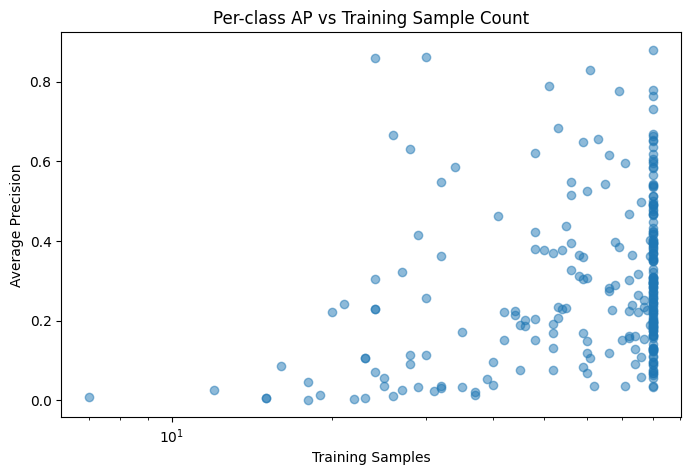

In [ ]:
train_counts = metadata_df[metadata_df["fold"] != 0]["ebird_code"].value_counts()
ap_df["train_samples"] = ap_df["species"].map(train_counts).fillna(0)

correlation = ap_df["AP"].corr(ap_df["train_samples"])
print(f"Correlation between AP and training samples count: {correlation:.3f}")

plt.figure(figsize=(8,5))
plt.scatter(ap_df["train_samples"], ap_df["AP"], alpha=0.5)
plt.xlabel("Training Samples")
plt.ylabel("Average Precision")
plt.title("Per-class AP vs Training Sample Count")
plt.xscale("log")
plt.show()